# 03 · Calorie Prediction Model
**CalixAI** — trains RandomForestRegressor and saves `calorie_model.pkl` + `calorie_scaler.pkl`.

In [1]:
import numpy as np
import pandas as pd
import pickle, os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings; warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid')

BASE       = os.path.abspath('..')
MODELS_DIR = os.path.join(BASE, 'models')

df       = pd.read_csv(os.path.join(BASE,'data','raw','calisthenics_dataset.csv'))
encoders = pickle.load(open(os.path.join(MODELS_DIR,'encoders.pkl'),'rb'))

for col in ['gender','fitness_level','goal','exercise','intensity']:
    df[col+'_enc'] = encoders[col].transform(df[col])

# Must match exactly the 16 features app.py builds
FEATURES = [
    'age','gender_enc','height_cm','weight_kg','bmi',
    'fitness_level_enc','exercise_enc','duration_min','intensity_enc',
    'sets','reps','heart_rate_avg','training_volume','effort_score',
    'metabolic_proxy','hr_reserve_ratio',
]

X = df[FEATURES].values
y = df['calories_burned'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler     = StandardScaler()
X_train_s  = scaler.fit_transform(X_train)
X_test_s   = scaler.transform(X_test)

print(f'Train: {X_train.shape[0]} | Test: {X_test.shape[0]}')

Train: 9600 | Test: 2400


In [2]:
model = RandomForestRegressor(
    n_estimators=300, max_depth=14, min_samples_split=4,
    min_samples_leaf=2, random_state=42, n_jobs=-1
)
model.fit(X_train_s, y_train)

y_pred = model.predict(X_test_s)
mae    = mean_absolute_error(y_test, y_pred)
rmse   = np.sqrt(mean_squared_error(y_test, y_pred))
r2     = r2_score(y_test, y_pred)
mape   = np.mean(np.abs((y_test - y_pred)/y_test))*100

print(f'MAE  : {mae:.2f} kcal')
print(f'RMSE : {rmse:.2f} kcal')
print(f'R2   : {r2:.4f}')
print(f'MAPE : {mape:.2f}%')

cv = cross_val_score(model, scaler.fit_transform(X), y, cv=5, scoring='r2', n_jobs=-1)
print(f'5-CV R2: {cv.mean():.4f} +/- {cv.std():.4f}')

MAE  : 41.90 kcal
RMSE : 68.10 kcal
R2   : 0.9437
MAPE : 10.57%
5-CV R2: 0.9428 +/- 0.0043


In [3]:
# Save
with open(os.path.join(MODELS_DIR,'calorie_model.pkl'),'wb') as f: pickle.dump(model, f)
with open(os.path.join(MODELS_DIR,'calorie_scaler.pkl'),'wb') as f: pickle.dump(scaler, f)
print('Saved: calorie_model.pkl + calorie_scaler.pkl')

Saved: calorie_model.pkl + calorie_scaler.pkl


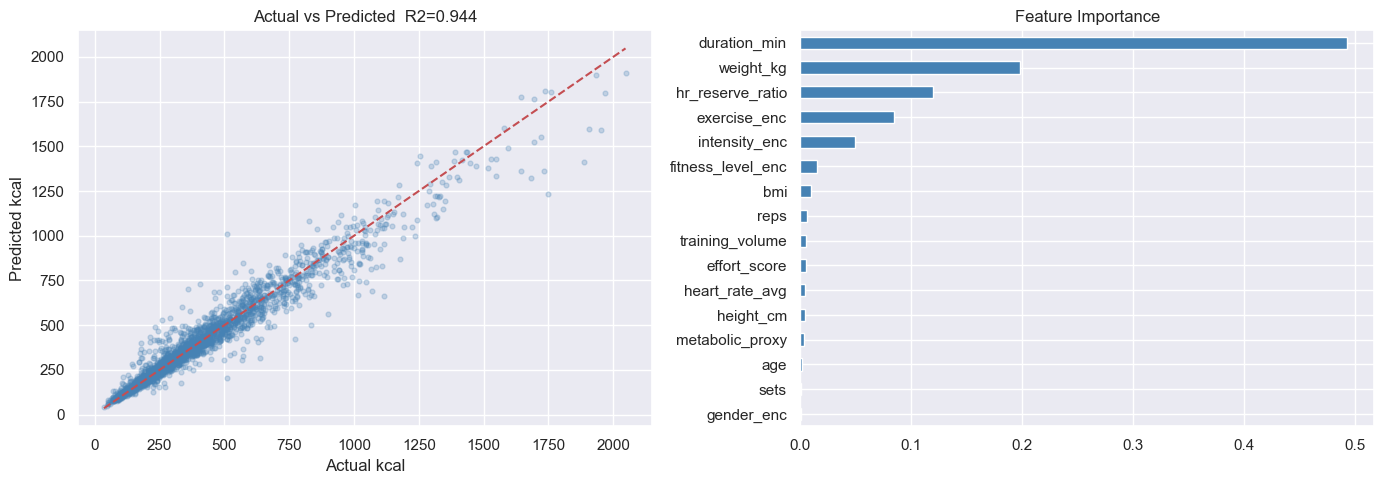

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_pred, alpha=0.25, s=12, color='steelblue')
lims = [y_test.min(), y_test.max()]
axes[0].plot(lims, lims, 'r--', lw=1.5)
axes[0].set_title(f'Actual vs Predicted  R2={r2:.3f}')
axes[0].set_xlabel('Actual kcal'); axes[0].set_ylabel('Predicted kcal')

imp = pd.Series(model.feature_importances_, index=FEATURES).sort_values()
imp.plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Feature Importance')

plt.tight_layout(); plt.show()